In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time

BASE_URL = "https://insideairbnb.com/get-the-data/"

headers = {"User-Agent": "Mozilla/5.0"}

def get_csv_links():
    r = requests.get(BASE_URL, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    links = []
    for a in soup.find_all("a"):
        href = a.get("href")
        if href and "listings.csv" in href:
            links.append(href)

    return links[:8]  # limit for assignment


def load_data(url):
    try:
        df = pd.read_csv(url)
        df["source"] = url
        df["scraped_at"] = pd.Timestamp.now()
        return df
    except:
        return None


all_dfs = []

links = get_csv_links()
print("Found:", len(links))

for i, link in enumerate(links):
    print(f"Scraping {i+1}/{len(links)}")

    df = load_data(link)
    if df is not None:
        all_dfs.append(df)

    time.sleep(2)

final_df = pd.concat(all_dfs, ignore_index=True)
final_df.to_csv("data_raw.csv", index=False)

print("Dataset created successfully!")

Found: 8
Scraping 1/8
Scraping 2/8
Scraping 3/8
Scraping 4/8
Scraping 5/8
Scraping 6/8
Scraping 7/8
Scraping 8/8
Dataset created successfully!


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data_raw.csv")

# -----------------------
# CLEANING
# -----------------------
df = df.dropna(subset=["price", "number_of_reviews"])

df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)

# -----------------------
# TARGET VARIABLE
# -----------------------
median_reviews = df["number_of_reviews"].median()
df["popular"] = (df["number_of_reviews"] > median_reviews).astype(int)

# -----------------------
# FEATURE ENGINEERING
# -----------------------
df["price_per_night"] = df["price"] / (df["minimum_nights"] + 1)

df["review_intensity"] = df["number_of_reviews"] / (df["availability_365"] + 1)

df["value_score"] = df["number_of_reviews"] / (df["price"] + 1)

df["host_activity"] = df["calculated_host_listings_count"]

df["location_score"] = df["latitude"] * df["longitude"]

# -----------------------
# SAVE CLEAN DATA
# -----------------------
df.to_csv("data_clean.csv", index=False)

print("Preprocessing complete")

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_443/470302027.py:11: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_443/470302027.py:4: DtypeWarning: Columns (12,34,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_raw.csv")


Preprocessing complete


/tmp/ipykernel_443/2323670257.py:5: DtypeWarning: Columns (34,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_clean.csv")


                 id     scrape_id       host_id  host_profile_id  \
count  2.111800e+04  1.055900e+04  2.111800e+04              0.0   
mean   6.526402e+17  2.025092e+13  1.746359e+08              NaN   
std    5.752266e+17  7.118010e+06  1.953535e+08              NaN   
min    2.788600e+04  2.025091e+13  3.592000e+03              NaN   
25%    3.580079e+07  2.025091e+13  1.992984e+07              NaN   
50%    7.671779e+17  2.025091e+13  8.419797e+07              NaN   
75%    1.183904e+18  2.025092e+13  2.801303e+08              NaN   
max    1.517509e+18  2.025093e+13  7.194141e+08              NaN   

       host_profile_url  hosts_time_as_user_years  hosts_time_as_user_months  \
count               0.0                       0.0                        0.0   
mean                NaN                       NaN                        NaN   
std                 NaN                       NaN                        NaN   
min                 NaN                       NaN                  

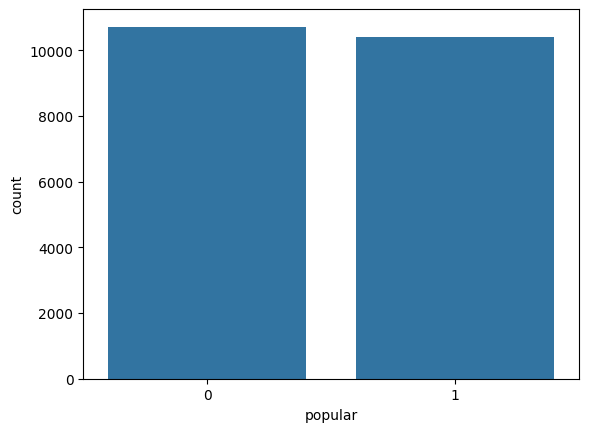

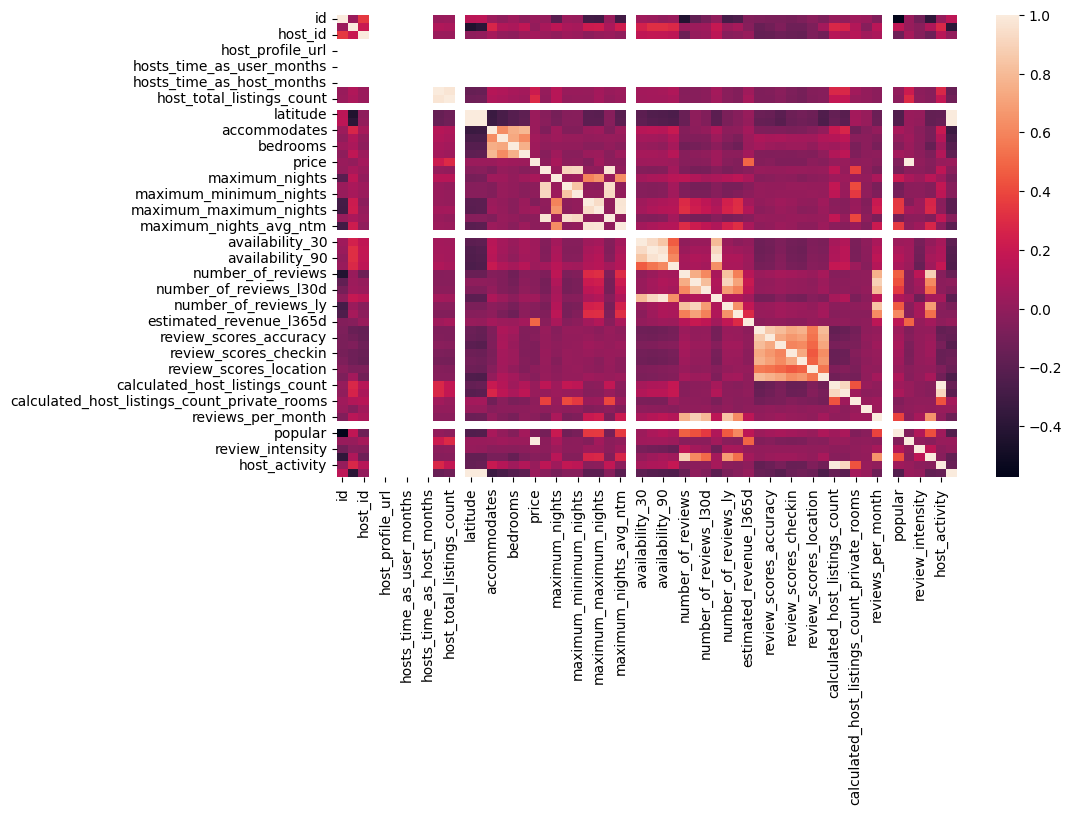

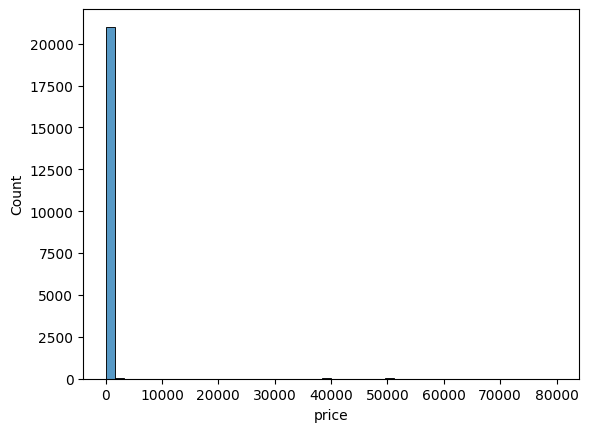

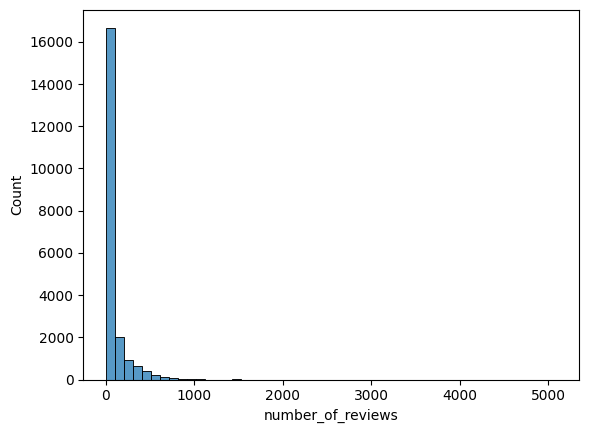

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data_clean.csv")

print(df.describe())
print(df.info())

# Popular vs Non-popular distribution
sns.countplot(x="popular", data=df)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.show()

# Price distribution
sns.histplot(df["price"], bins=50)
plt.show()

# Reviews distribution
sns.histplot(df["number_of_reviews"], bins=50)
plt.show()

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import joblib

df = pd.read_csv("data_clean.csv")

features = [
    "price",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "price_per_night",
    "review_intensity",
    "value_score",
    "host_activity"
]

X = df[features].fillna(0)
y = df["popular"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "LogisticRegression": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

best_model = None
best_score = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("\n", name)
    print(classification_report(y_test, pred))

    score = model.score(X_test, y_test)

    if score > best_score:
        best_score = score
        best_model = model

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Best model saved!")

/tmp/ipykernel_443/3817480981.py:14: DtypeWarning: Columns (34,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_clean.csv")



 LogisticRegression
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2144
           1       0.99      0.96      0.97      2080

    accuracy                           0.98      4224
   macro avg       0.98      0.98      0.98      4224
weighted avg       0.98      0.98      0.98      4224


 DecisionTree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2144
           1       1.00      1.00      1.00      2080

    accuracy                           1.00      4224
   macro avg       1.00      1.00      1.00      4224
weighted avg       1.00      1.00      1.00      4224


 RandomForest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2144
           1       1.00      1.00      1.00      2080

    accuracy                           1.00      4224
   macro avg       1.00      1.00      1.00      4224
weighted avg       1.00

/tmp/ipykernel_443/2129197409.py:5: DtypeWarning: Columns (34,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_clean.csv")


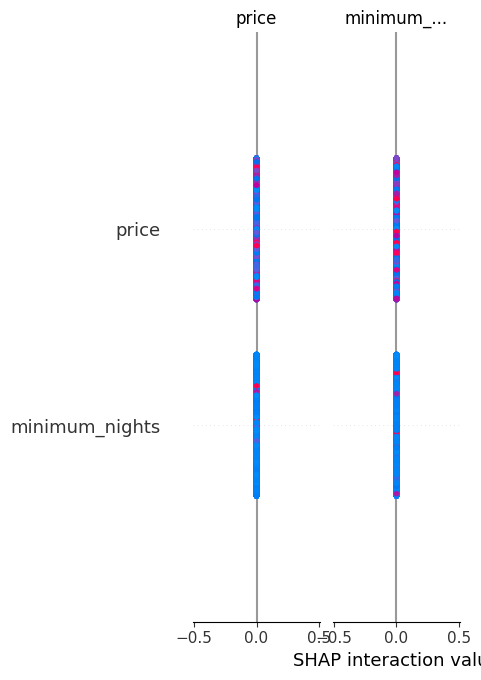

In [5]:
import pandas as pd
import joblib
import shap

df = pd.read_csv("data_clean.csv")

model = joblib.load("model.pkl")

features = [
    "price",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "price_per_night",
    "review_intensity",
    "value_score",
    "host_activity"
]

X = df[features].fillna(0)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)